# K-Nearest Neighbors: The Lazy Learner

## What is KNN?

K-Nearest Neighbors (KNN) stands apart from other supervised learning algorithms in a fundamental way: **it has no training phase**. While algorithms like linear regression, SVMs, or neural networks spend time fitting parameters to data, KNN simply memorizes the training set and defers all computation to prediction time.

This makes KNN:
- **Conceptually simple:** easy to explain and implement
- **An instance-based learner:** predictions come from stored examples, not learned parameters
- **A "lazy" algorithm:** no work upfront, all work at query time

### The Core Principle

KNN embodies a simple intuition: **similar inputs should produce similar outputs**. To predict the label for a new point, just look at what labels its neighbors have.

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.datasets import load_iris, load_wine, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## The KNN Algorithm

Given a new point $P$ to classify:

1. **Compute distances** from $P$ to every point in the training set
2. **Select** the $k$ points with smallest distances (the "k nearest neighbors")
3. **Aggregate** their labels:
   - *Classification*: majority vote among neighbors
   - *Regression*: average of neighbor values

No optimization, no gradients, no parameter updates, just distance calculations and counting.

### Visual Walkthrough

Let's classify an unknown green point using its 3 nearest neighbors:

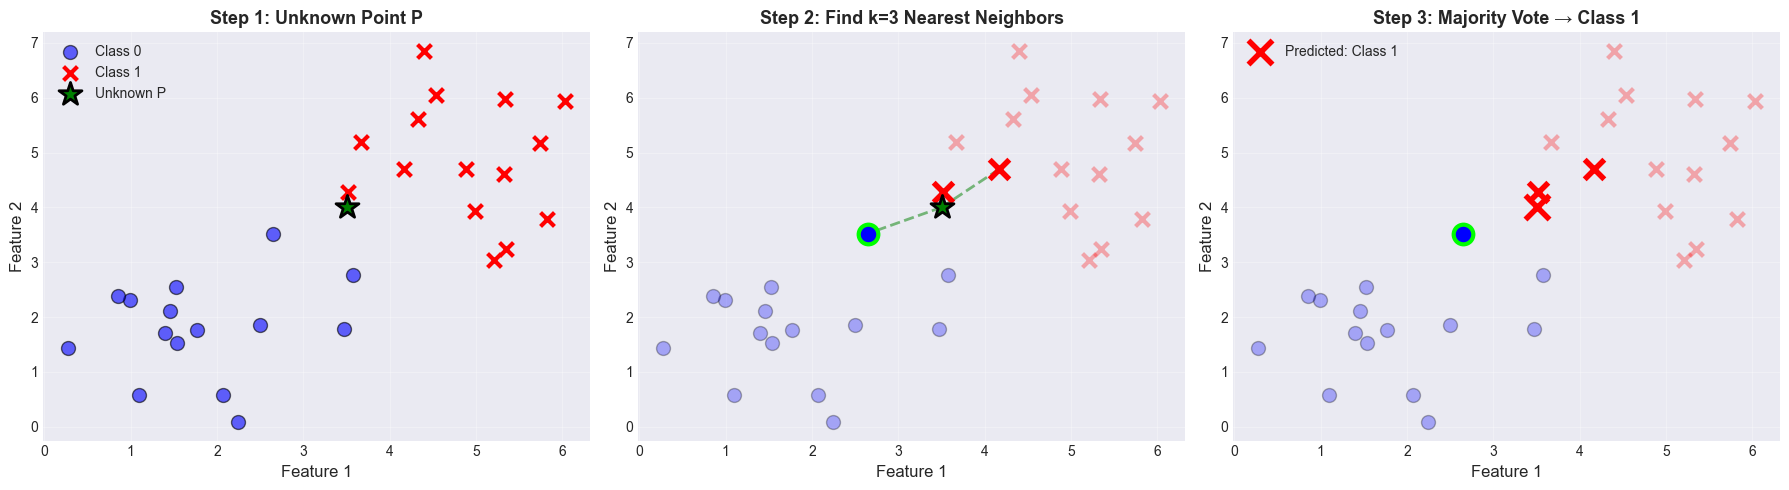


🎯 Neighbor votes: [1 1 0]
   Class 0: 1 votes
   Class 1: 2 votes

✨ Prediction: Class 1 (majority wins!)


In [2]:
# Visualize KNN concept
np.random.seed(42)

# Generate sample data
X_class0 = np.random.randn(15, 2) + np.array([2, 2])
X_class1 = np.random.randn(15, 2) + np.array([5, 5])
X_train = np.vstack([X_class0, X_class1])
y_train = np.array([0]*15 + [1]*15)

# Unknown point
P = np.array([3.5, 4.0])

# Find k=3 nearest neighbors
distances = np.sqrt(np.sum((X_train - P)**2, axis=1))
k_nearest_idx = np.argsort(distances)[:3]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Step 1: Show unknown point
ax = axes[0]
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
          c='blue', s=100, alpha=0.6, edgecolors='k', label='Class 0')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
          c='red', marker='x', s=100, linewidths=3, label='Class 1')
ax.scatter(P[0], P[1], c='green', s=300, marker='*', 
          edgecolors='black', linewidths=2, label='Unknown P', zorder=5)
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Step 1: Unknown Point P', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Step 2: Show k-nearest neighbors
ax = axes[1]
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
          c='blue', s=100, alpha=0.3, edgecolors='k')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
          c='red', marker='x', s=100, linewidths=3, alpha=0.3)
ax.scatter(P[0], P[1], c='green', s=300, marker='*', 
          edgecolors='black', linewidths=2, zorder=5)

# Highlight k-nearest
for idx in k_nearest_idx:
    ax.plot([P[0], X_train[idx, 0]], [P[1], X_train[idx, 1]], 
           'g--', linewidth=2, alpha=0.5)
    if y_train[idx] == 0:
        ax.scatter(X_train[idx, 0], X_train[idx, 1], 
                  c='blue', s=200, edgecolors='lime', linewidths=3, zorder=4)
    else:
        ax.scatter(X_train[idx, 0], X_train[idx, 1], 
                  c='red', marker='x', s=200, linewidths=4, zorder=4)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Step 2: Find k=3 Nearest Neighbors', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Step 3: Assign label
ax = axes[2]
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
          c='blue', s=100, alpha=0.3, edgecolors='k')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
          c='red', marker='x', s=100, linewidths=3, alpha=0.3)

# Count votes
neighbor_labels = y_train[k_nearest_idx]
predicted_label = 1 if sum(neighbor_labels) >= 2 else 0

# Highlight k-nearest with their labels
for idx in k_nearest_idx:
    if y_train[idx] == 0:
        ax.scatter(X_train[idx, 0], X_train[idx, 1], 
                  c='blue', s=200, edgecolors='lime', linewidths=3, zorder=4)
    else:
        ax.scatter(X_train[idx, 0], X_train[idx, 1], 
                  c='red', marker='x', s=200, linewidths=4, zorder=4)

# Show predicted point
if predicted_label == 0:
    ax.scatter(P[0], P[1], c='blue', s=300, edgecolors='black', 
              linewidths=3, label='Predicted: Class 0', zorder=5)
else:
    ax.scatter(P[0], P[1], c='red', marker='x', s=300, 
              linewidths=4, label='Predicted: Class 1', zorder=5)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title(f'Step 3: Majority Vote → Class {predicted_label}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Neighbor votes: {neighbor_labels}")
print(f"   Class 0: {sum(neighbor_labels == 0)} votes")
print(f"   Class 1: {sum(neighbor_labels == 1)} votes")
print(f"\n✨ Prediction: Class {predicted_label} (majority wins!)")

## The Computational Trade-off

KNN inverts the typical computational profile of ML algorithms:

| | Traditional Models | KNN |
|---|---|---|
| **Training** | Expensive (optimize parameters) | Free (just store data) |
| **Prediction** | Fast (apply learned function) | Expensive (compute all distances) |
| **Memory** | Store model parameters | Store entire dataset |

### Why Prediction is Slow

For each query point, KNN must:
1. Calculate distance to **every** training point. $O(n \cdot d)$ where $n$ = samples, $d$ = dimensions
2. Sort or partition to find the $k$ smallest. $O(n \log n)$ or $O(n)$ with clever data structures
3. Aggregate neighbor labels. $O(k)$

With large training sets, this becomes prohibitively slow for real-time applications.

**Note:** Approximate nearest neighbor methods (KD-trees, ball trees, locality-sensitive hashing) can accelerate queries, but KNN remains fundamentally slower at prediction than parametric models.

## Distance Metrics

"Nearest" requires defining distance. The choice of metric affects which points are considered neighbors.

### Common Metrics

For points $\mathbf{u} = (u_1, \ldots, u_d)$ and $\mathbf{v} = (v_1, \ldots, v_d)$:

**Euclidean (L2)** — straight-line distance:
$$d_2(\mathbf{u}, \mathbf{v}) = \sqrt{\sum_{i=1}^{d} (u_i - v_i)^2}$$

**Manhattan (L1)** — sum of axis-aligned distances:
$$d_1(\mathbf{u}, \mathbf{v}) = \sum_{i=1}^{d} |u_i - v_i|$$

**Minkowski (Lp)** — generalization:
$$d_p(\mathbf{u}, \mathbf{v}) = \left(\sum_{i=1}^{d} |u_i - v_i|^p\right)^{1/p}$$

- $p=1$ recovers Manhattan
- $p=2$ recovers Euclidean
- $p \to \infty$ gives Chebyshev distance (max coordinate difference)

**Default choice:** Euclidean works well for continuous features with similar scales. Manhattan can be preferable for sparse data or when features have different meanings.

## Choosing k: The Bias-Variance Trade-off

The hyperparameter $k$ controls model complexity:

### Small k (e.g., k=1)
- Decision boundary follows individual training points closely
- **High variance**: sensitive to noise and outliers
- Risk of **overfitting**

### Large k
- Decision boundary smooths over local variations
- **Lower variance**: more stable predictions
- Risk of **underfitting** (ignoring local structure)

### Finding the Sweet Spot

The optimal $k$ depends on:
- Dataset size and noise level
- Class separability
- Dimensionality

**Best practice:** Use cross-validation to select $k$. Common starting points: $k = \sqrt{n}$ or odd values to avoid ties in binary classification.

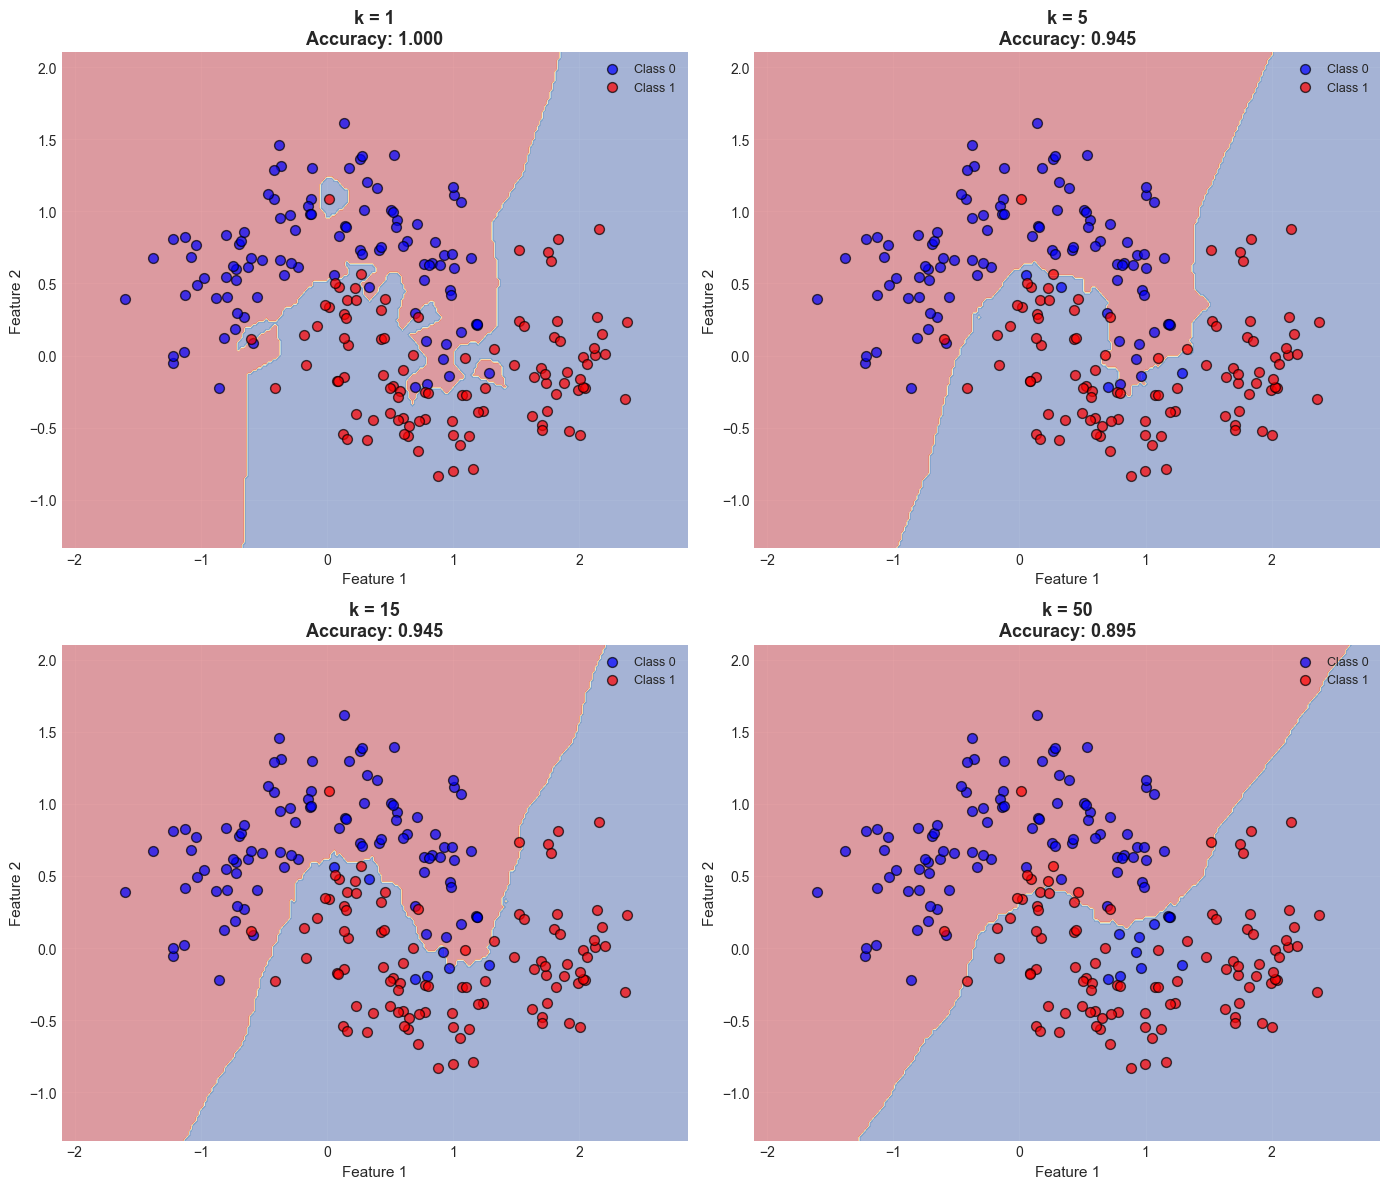


📊 Effect of K:
  • k=1:  Very jagged boundary (overfitting)
  • k=5:  Good balance
  • k=15: Smoother boundary
  • k=50: Too smooth (underfitting)


In [3]:
# Visualize effect of different k values
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

k_values = [1, 5, 15, 50]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    
    # Create decision boundary
    ax = axes[idx]
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=50, alpha=0.7, 
              edgecolors='k', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red', s=50, alpha=0.7, 
              edgecolors='k', label='Class 1')
    
    accuracy = knn.score(X, y)
    ax.set_title(f'k = {k}\nAccuracy: {accuracy:.3f}', 
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Effect of K:")
print("  • k=1:  Very jagged boundary (overfitting)")
print("  • k=5:  Good balance")
print("  • k=15: Smoother boundary")
print("  • k=50: Too smooth (underfitting)")

## Why Feature Scaling is Essential

Distance-based algorithms are sensitive to feature magnitudes. If one feature ranges from 0-1000 while another ranges 0-1, the first will dominate distance calculations entirely.

**Always standardize features** before applying KNN (e.g., z-score normalization or min-max scaling).

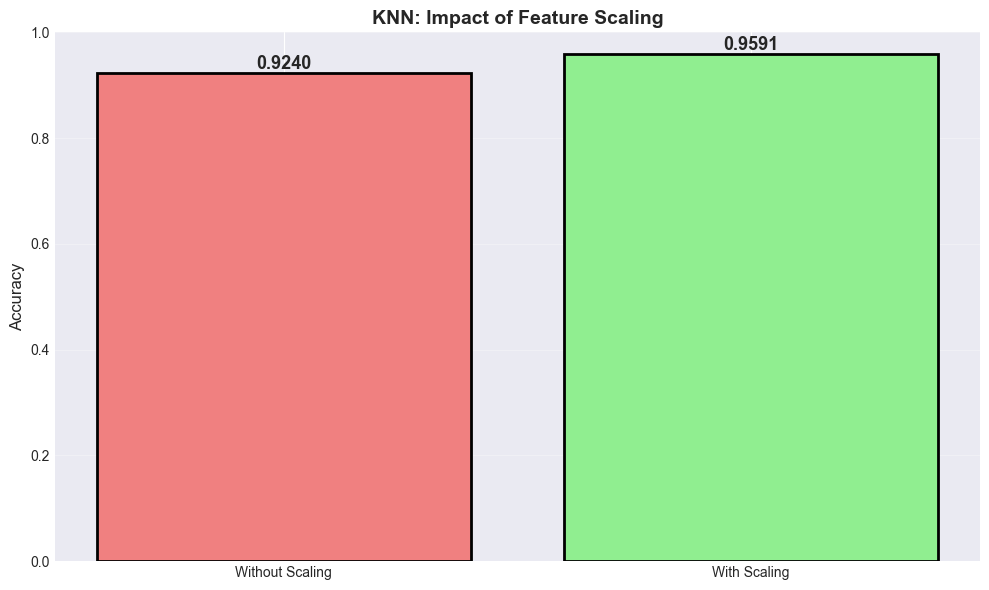


⚠️ Feature Scaling is CRITICAL for KNN!
Without scaling: 0.9240
With scaling:    0.9591
Improvement:     3.51%

💡 Why? Features with larger scales dominate distance calculations!


In [4]:
# Demonstrate importance of scaling
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer
)

# Without scaling
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train_c, y_train_c)
acc_unscaled = knn_unscaled.score(X_test_c, y_test_c)

# With scaling
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_c_scaled, y_train_c)
acc_scaled = knn_scaled.score(X_test_c_scaled, y_test_c)

# Visualize difference
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Without Scaling', 'With Scaling']
accuracies = [acc_unscaled, acc_scaled]
colors = ['lightcoral', 'lightgreen']

bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('KNN: Impact of Feature Scaling', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{acc:.4f}', ha='center', va='bottom', 
           fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️ Feature Scaling is CRITICAL for KNN!")
print("="*60)
print(f"Without scaling: {acc_unscaled:.4f}")
print(f"With scaling:    {acc_scaled:.4f}")
print(f"Improvement:     {(acc_scaled - acc_unscaled)*100:.2f}%")
print("\n💡 Why? Features with larger scales dominate distance calculations!")

## The Curse of Dimensionality

KNN's effectiveness degrades as dimensionality increases. This phenomenon, called the **curse of dimensionality**, arises because high-dimensional spaces are inherently sparse.

### What Happens in High Dimensions

As $d$ (number of features) grows:
- The volume of the feature space grows exponentially
- Data points become increasingly isolated
- All pairwise distances converge toward similar values
- The concept of "nearest" becomes meaningless

### Distance Concentration

Mathematically, as dimensionality increases:
- The **mean distance** between random points grows as $\sqrt{d}$
- The **standard deviation** of distances grows more slowly
- The **coefficient of variation** (std/mean) shrinks toward zero

When distances have low relative variance, the nearest neighbor isn't meaningfully closer than the farthest and KNN loses its discriminative power.

### Practical Guidelines

- KNN works best with **< 20-30 features**
- For high-dimensional data, consider:
  - **Dimensionality reduction** (PCA, t-SNE, UMAP)
  - **Feature selection** (remove irrelevant features)
  - **Different algorithms** that don't rely on raw distances

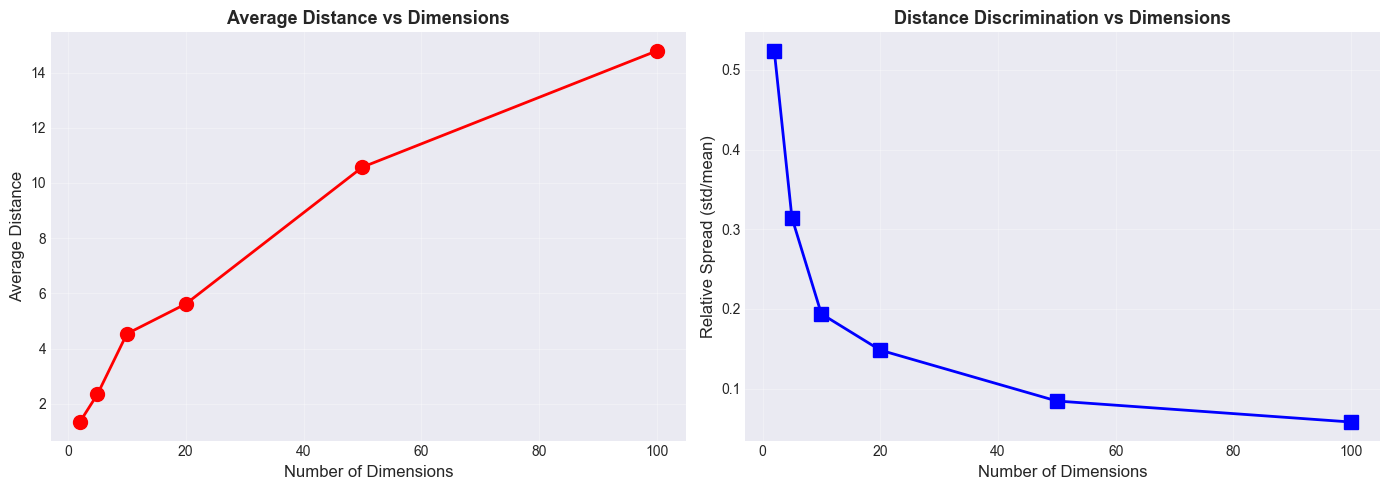


🚨 Curse of Dimensionality:
Dimensions:   2 | Avg Distance:   1.34 | Discrimination: 0.5239
Dimensions:   5 | Avg Distance:   2.35 | Discrimination: 0.3144
Dimensions:  10 | Avg Distance:   4.54 | Discrimination: 0.1938
Dimensions:  20 | Avg Distance:   5.62 | Discrimination: 0.1483
Dimensions:  50 | Avg Distance:  10.57 | Discrimination: 0.0844
Dimensions: 100 | Avg Distance:  14.78 | Discrimination: 0.0580

💡 As dimensions increase:
   • Average distance grows
   • Relative spread (discrimination) decreases
   • All points become roughly equidistant!


In [5]:
# Demonstrate curse of dimensionality
n_samples = 1000
dimensions = [2, 5, 10, 20, 50, 100]
avg_distances = []
std_distances = []

for d in dimensions:
    # Generate random data
    X_random = np.random.randn(n_samples, d)
    
    # Pick a random point and compute distances to all others
    point = X_random[0]
    distances = np.sqrt(np.sum((X_random[1:] - point)**2, axis=1))
    
    avg_distances.append(np.mean(distances))
    std_distances.append(np.std(distances))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average distance
ax = axes[0]
ax.plot(dimensions, avg_distances, 'o-', linewidth=2, markersize=10, color='red')
ax.set_xlabel('Number of Dimensions', fontsize=12)
ax.set_ylabel('Average Distance', fontsize=12)
ax.set_title('Average Distance vs Dimensions', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Relative spread
ax = axes[1]
relative_spread = np.array(std_distances) / np.array(avg_distances)
ax.plot(dimensions, relative_spread, 's-', linewidth=2, markersize=10, color='blue')
ax.set_xlabel('Number of Dimensions', fontsize=12)
ax.set_ylabel('Relative Spread (std/mean)', fontsize=12)
ax.set_title('Distance Discrimination vs Dimensions', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🚨 Curse of Dimensionality:")
print("="*60)
for d, avg, rel in zip(dimensions, avg_distances, relative_spread):
    print(f"Dimensions: {d:3d} | Avg Distance: {avg:6.2f} | Discrimination: {rel:.4f}")
print("\n💡 As dimensions increase:")
print("   • Average distance grows")
print("   • Relative spread (discrimination) decreases")
print("   • All points become roughly equidistant!")

## Summary

### Core Concepts

1. **No training phase:** KNN memorizes data and computes predictions on-the-fly

2. **Prediction mechanism:**
   - Find $k$ nearest neighbors by distance
   - Classification: majority vote
   - Regression: average value

3. **Computational profile:**
   - Training: $O(1)$ (just store data)
   - Prediction: $O(nd)$ per query (expensive)
   - Memory: must store entire training set

4. **Distance metrics:**
   - Euclidean (L2) — default, good for continuous features
   - Manhattan (L1) — for grid-like or sparse data
   - Choice affects neighbor selection

5. **Hyperparameter k:**
   - Small k → high variance, overfitting risk
   - Large k → high bias, underfitting risk
   - Tune via cross-validation

6. **Feature scaling is mandatory:** unscaled features distort distances

7. **Curse of dimensionality:**
   - With high dimensions, distances become uninformative
   - Best with < 20-30 features
   - Consider dimensionality reduction for high-d data


## Strengths 

- Simple and intuitive
- No training time
- Non-parametric (no distributional assumptions)
- Naturally handles multi-class problems
- Works for both classification and regression
- Easy to interpret ("similar examples")

## Limitations

- Slow predictions (scales with dataset size)
- Memory-intensive (stores all training data)
- Struggles in high dimensions
- Sensitive to feature scaling
- Sensitive to irrelevant features
- Requires tuning k
- Can struggle with class imbalance


## When to Use KNN

**Good for:**
- Small to medium datasets
- Low-dimensional feature spaces (< 20 features)
- Non-linear decision boundaries
- Quick baseline models
- When you can't assume a parametric form
- Pattern recognition and recommendation systems

**Avoid when:**
- Large training sets (slow prediction)
- High-dimensional data (curse of dimensionality)
- Real-time prediction requirements
- Memory is constrained
- Many irrelevant or noisy features